## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | DenseNet-121 Paired-View YOLO Crop Adaptation |
| Model / workflow | DenseNet-121/201 |
| Input | not reported |
| Loss | Cross-Entropy (CE) |
| Training / pipeline | Paired-view adaptation/evaluation |
| Result | Checkpoint candidate: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation ( * )/ce/best_model.pth / S...; Checkpoint candidate: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-2... |


# DenseNet-121 Paired-View YOLO Crop Adaptation

This validation-only experiment tests whether occasional production-YOLO views can improve crop robustness without discarding the higher-detail published crops. All three arms begin from the same selected DenseNet-121 checkpoint and receive exactly five full-network fine-tuning epochs.

Arms:

- `published_control`: published crop only.
- `paired_raw_x1_00`: 50% published crop and 50% raw production-YOLO crop.
- `paired_expanded_x1_15`: 50% published crop and 50% `1.15x` production-YOLO crop.

The test and `auto_test` folders are never accessed. This experiment does not claim that low-resolution HDF5 crops reproduce full-resolution clinical acquisition.

The untouched base checkpoint is also evaluated and remains eligible to win. Therefore, the notebook can conclude that neither adaptation arm is suitable.

In [3]:
!pip -q install "timm>=1.0,<2" "ultralytics>=8.3,<9" "h5py>=3.9" "scikit-learn>=1.4" seaborn tabulate

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import hashlib
import json
import math
import os
import random
import re
import shutil
from datetime import datetime, timezone
from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm
from ultralytics import YOLO


def sha256_file(path, block_size=4 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y-%m-%d_%H-%M-%S_%f_UTC')
RUN_NAME = f'{RUN_TIMESTAMP}_paired_view_yolo_crop_adaptation'
LOCAL_RUN_DIR = Path('/content') / RUN_NAME
DRIVE_RUN_DIR = Path('/content/drive/MyDrive/Models/densenet121_paired_view_ablations') / RUN_NAME
LOCAL_RUN_DIR.mkdir(parents=True, exist_ok=False)

DATA_ROOT = Path('/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/extracted/KneeXrayData')
H5_ROOT = DATA_ROOT / 'DetKneeData/H5'
PUBLISHED_ROOT = DATA_ROOT / 'ClsKLData/kneeKL224'
YOLO_CHECKPOINT = Path('/content/drive/MyDrive/Models/yolov8_checkpoint/best.pt')
EXPECTED_YOLO_SHA256 = '443003a317ca71f3f63e0f5ac145a0eafa431053a998dbb4c60c65b5c5e7fef7'
EXPECTED_BASE_SHA256 = '2d9c6e048c6e0fbcdc74727c72c55082e1137bb8e18b1984737fbd5eb7baecbb'
EXPECTED_ARCHITECTURE = 'timm_densenet121_linear_gradcam'
SPLITS = ('train', 'val')
EXPECTED_H5 = {'train': 2889, 'val': 413}
EXPECTED_KNEES = {'train': 5778, 'val': 826}
EXPANSION_FACTORS = (1.00, 1.15)
INPUT_SIZE = 384
BATCH_SIZE = 48
NUM_WORKERS = 2
EPOCHS = 5
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-3
YOLO_CONFIDENCE = 0.45
YOLO_IMGSZ = 640
YOLO_BATCH_SIZE = 32
ALTERNATE_VIEW_PROBABILITY = 0.50
GRADES = tuple(range(5))

ARM_SPECS = (
    {'name': 'published_control', 'alternate_factor': None},
    {'name': 'paired_raw_x1_00', 'alternate_factor': 1.00},
    {'name': 'paired_expanded_x1_15', 'alternate_factor': 1.15},
)


def resolve_base_checkpoint():
    models_root = Path('/content/drive/MyDrive/Models')
    preferred = [
        models_root / 'densenet121_checkpoints/2026-07-29_00-58-22_554974_UTC_natural_orientation_ce_gradcam/best_model.pth',
        models_root / 'densenet121_checkpoints/best_model.pth',
        models_root / 'densenet121/best_model.pth',
        models_root / 'densenet121_checkpoint/best_model.pth',
    ]
    checked = set()

    def check(candidate):
        candidate = Path(candidate)
        if candidate in checked or not candidate.is_file():
            return None
        checked.add(candidate)
        digest = sha256_file(candidate)
        print(f'Checkpoint candidate: {candidate} | SHA-256={digest}')
        return candidate if digest == EXPECTED_BASE_SHA256 else None

    for candidate in preferred:
        match = check(candidate)
        if match is not None:
            return match

    if models_root.is_dir():
        discovered = sorted(
            path for path in models_root.rglob('*.pth')
            if 'best' in path.name.lower()
            and any(token in str(path).lower() for token in ('densenet121', 'dense_net_121', 'denset121'))
        )
        for candidate in discovered:
            match = check(candidate)
            if match is not None:
                return match

    raise FileNotFoundError(
        'Could not locate the exact DenseNet-121 base checkpoint. '
        f'Expected SHA-256: {EXPECTED_BASE_SHA256}. '
        'Copy that checkpoint anywhere under /content/drive/MyDrive/Models in a DenseNet-named folder.'
    )


for required in (H5_ROOT, PUBLISHED_ROOT, YOLO_CHECKPOINT):
    if not required.exists():
        raise FileNotFoundError(f'Required path not found: {required}')
BASE_CHECKPOINT = resolve_base_checkpoint()

print('Device:', DEVICE)
print('Run:', RUN_NAME)
print('Base checkpoint:', BASE_CHECKPOINT)
print('Validation-only model selection; test and auto_test are not accessed.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint candidate: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation ( * )/ce/best_model.pth | SHA-256=27854d6f160ca9455c61ed160dd2ccb2994b4e7f94c313270f69718314284400
Checkpoint candidate: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation ( * )/ce/stage2_best_model.pth | SHA-256=4c2a1230331ecbfd9e04954754e20101714b6685bc63ff00c6bffbdcc6a7130d
Checkpoint candidate: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss_ablation ( * )/ce_plus_ordinal_pd2/best_model.pth | SHA-256=b8eee143a99d0bceff61b69612c555947c7dcd712e5d515299736f0d7a101931
Checkpoint candidate: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_06-30-25_175448_UTC_final_noncanonical_loss

## Build labels and production-YOLO views

YOLO runs once over the train and validation HDF5 images. The same detections produce both raw and `1.15x` views. Published crops remain the primary source of radiographic detail.

In [5]:
# published filenames are {patient_id}{L|R}.png, e.g. 9059946L.png
# the named groups split that into patient '9059946' and side 'L'.
# the HDF5 files are named by patient only, because one file holds BOTH knees -
# so this pattern is the bridge between the two naming schemes
LABEL_PATTERN = re.compile(r'^(?P<patient>\d+)(?P<side>[RL])$', re.IGNORECASE)


# read the KL grade of every knee from the published folder layout
# (folder name = grade), and fail loudly if a split does not have the expected
# count. a silent short read here would corrupt every downstream label
def build_label_frame():
    rows = []
    for split in SPLITS:
        for grade in GRADES:
            for path in sorted((PUBLISHED_ROOT / split / str(grade)).glob('*.png')):
                match = LABEL_PATTERN.match(path.stem)
                if not match:
                    raise ValueError(f'Unexpected filename: {path.name}')
                rows.append({
                    'split': split,
                    'patient_id': match.group('patient'),
                    'side': match.group('side').upper(),
                    'grade': grade,
                    'published_path': str(path),
                })
    frame = pd.DataFrame(rows)
    for split in SPLITS:
        count = int((frame.split == split).sum())
        if count != EXPECTED_KNEES[split]:
            raise RuntimeError(f'{split}: expected {EXPECTED_KNEES[split]} labels, found {count}')
    return frame


# one HDF5 file = one full bilateral radiograph. handle greyscale (2-D) and
# RGBA by forcing everything to 3-channel uint8
def load_h5_image(path):
    with h5py.File(path, 'r') as handle:
        image = np.asarray(handle['images'])
    if image.ndim == 2:
        image = np.repeat(image[..., None], 3, axis=2)
    if image.shape[2] == 4:
        image = image[:, :, :3]
    return np.clip(image, 0, 255).astype(np.uint8)


# grow a YOLO box around its own centre, then clamp to the image edge.
# note this keeps the box's aspect ratio - it is NOT squared here, unlike the
# dataset-prep notebook which also forces a square side
# example: box 100x200, factor 1.15 -> 115x230, still centred on the same point
def expand_box(box, factor, width, height):
    x1, y1, x2, y2 = map(float, box)
    center_x, center_y = 0.5 * (x1 + x2), 0.5 * (y1 + y2)
    half_width = 0.5 * (x2 - x1) * factor
    half_height = 0.5 * (y2 - y1) * factor
    return [
        max(0, int(math.floor(center_x - half_width))),
        max(0, int(math.floor(center_y - half_height))),
        min(width, int(math.ceil(center_x + half_width))),
        min(height, int(math.ceil(center_y + half_height))),
    ]


label_df = build_label_frame()
label_index = {
    (row.split, row.patient_id, row.side): row
    for row in label_df.itertuples(index=False)
}

# hash both checkpoints and refuse to run if the detector is not the expected file.
# the whole ablation is about ROI geometry, so a different detector would silently
# change the thing being measured
yolo_sha256 = sha256_file(YOLO_CHECKPOINT)
if yolo_sha256 != EXPECTED_YOLO_SHA256:
    raise RuntimeError(f'YOLO SHA-256 mismatch: {yolo_sha256}')
base_sha256 = sha256_file(BASE_CHECKPOINT)
print('YOLO SHA-256:', yolo_sha256)
print('Base checkpoint SHA-256:', base_sha256)
display(label_df.groupby(['split', 'grade']).size().unstack(fill_value=0))

YOLO SHA-256: 443003a317ca71f3f63e0f5ac145a0eafa431053a998dbb4c60c65b5c5e7fef7
Base checkpoint SHA-256: 2d9c6e048c6e0fbcdc74727c72c55082e1137bb8e18b1984737fbd5eb7baecbb


grade,0,1,2,3,4
split,,,,,
train,2286,1046,1516,757,173
val,328,153,212,106,27


In [6]:
# generate the alternate views once, for every expansion factor, before training.
# doing it up front means every arm reads identical pixels from disk instead of
# re-running the detector with its own randomness
yolo = YOLO(str(YOLO_CHECKPOINT))
generated_rows = []
rejected_rows = []

for split in SPLITS:
    h5_paths = sorted((H5_ROOT / f'{split}H5').glob('*.h5'))
    if len(h5_paths) != EXPECTED_H5[split]:
        raise RuntimeError(f'{split}: expected {EXPECTED_H5[split]} HDF5 files, found {len(h5_paths)}')
    for batch_start in tqdm(range(0, len(h5_paths), YOLO_BATCH_SIZE), desc=f'YOLO {split}'):
        batch_paths = h5_paths[batch_start:batch_start + YOLO_BATCH_SIZE]
        batch_rgb = [load_h5_image(path) for path in batch_paths]
        batch_bgr = [cv2.cvtColor(image, cv2.COLOR_RGB2BGR) for image in batch_rgb]
        predictions = yolo.predict(
            source=batch_bgr,
            conf=YOLO_CONFIDENCE,
            imgsz=YOLO_IMGSZ,
            device=0 if DEVICE.type == 'cuda' else 'cpu',
            batch=YOLO_BATCH_SIZE,
            save=False,
            verbose=False,
        )
        for h5_path, image_bgr, prediction in zip(batch_paths, batch_bgr, predictions):
            patient = h5_path.stem
            height, width = image_bgr.shape[:2]
            detections = [
                {
                    'box': detected.xyxy[0].detach().cpu().tolist(),
                    'confidence': float(detected.conf[0].item()),
                }
                for detected in prediction.boxes
            ]
            # keep the two most confident detections - one per knee
            selected = sorted(detections, key=lambda item: item['confidence'], reverse=True)[:2]
            # then re-sort those two by horizontal centre, left to right.
            # on a PA radiograph the patient's RIGHT knee appears on the LEFT of the image,
            # so the left-most box is 'R' and the right-most is 'L' (see the zip below)
            selected.sort(key=lambda item: 0.5 * (item['box'][0] + item['box'][2]))
            if len(selected) != 2:
                # record the failure and move on rather than crashing, so one bad radiograph
                # does not lose the whole run. the count is checked at the end
                rejected_rows.append({'split': split, 'patient_id': patient, 'reason': 'fewer_than_two_detections'})
                continue
            for detection, side in zip(selected, ('R', 'L')):
                label_row = label_index[(split, patient, side)]
                for factor in EXPANSION_FACTORS:
                    x1, y1, x2, y2 = expand_box(detection['box'], factor, width, height)
                    crop = image_bgr[y1:y2, x1:x2]
                    factor_name = f'x{factor:.2f}'.replace('.', '_')
                    output_path = LOCAL_RUN_DIR / 'generated_crops' / split / factor_name / str(label_row.grade) / f'{patient}{side}.png'
                    output_path.parent.mkdir(parents=True, exist_ok=True)
                    if crop.size == 0 or not cv2.imwrite(str(output_path), crop):
                        raise RuntimeError(f'Failed to write crop: {output_path}')
                    generated_rows.append({
                        'split': split, 'patient_id': patient, 'side': side,
                        'grade': int(label_row.grade),
                        'published_path': label_row.published_path,
                        'factor': factor,
                        'alternate_path': str(output_path),
                        'yolo_confidence': detection['confidence'],
                        'detection_count': len(detections),
                        'roi_width': x2 - x1, 'roi_height': y2 - y1,
                    })

generated_df = pd.DataFrame(generated_rows)
rejected_df = pd.DataFrame(rejected_rows)
generated_df.to_csv(LOCAL_RUN_DIR / 'paired_view_manifest.csv', index=False)
rejected_df.to_csv(LOCAL_RUN_DIR / 'rejected.csv', index=False)
expected_generated = sum(EXPECTED_KNEES.values()) * len(EXPANSION_FACTORS)
print(f'Generated {len(generated_df):,}/{expected_generated:,} alternate views')
# hard inventory check: every knee must have a crop at every factor, or stop
if len(generated_df) != expected_generated:
    raise RuntimeError('Incomplete alternate-view inventory; inspect rejected.csv')
display(generated_df.groupby(['split', 'factor']).agg(
    knees=('alternate_path', 'size'),
    mean_width=('roi_width', 'mean'),
    mean_height=('roi_height', 'mean'),
    mean_confidence=('yolo_confidence', 'mean'),
))

YOLO train:   0%|          | 0/91 [00:00<?, ?it/s]

YOLO val:   0%|          | 0/13 [00:00<?, ?it/s]

Generated 13,208/13,208 alternate views


knees  mean_width  mean_height  mean_confidence
split factor                                                 
train 1.00     5778   80.566459    73.517826         0.907734
      1.15     5778   92.413465    84.390447         0.907734
val   1.00      826   79.845036    72.979419         0.907470
      1.15      826   91.576271    83.769976         0.907470

## Fixed preprocessing, paired dataset, and DenseNet-121

Training preserves the complete ROI. It uses CLAHE 1.25, square padding, mild flip/rotation/brightness/contrast, conservative erasing, and ImageNet normalization. Validation is deterministic.

In [7]:
# CLAHE 1.25 on the L channel of LAB, then SquarePad - the order settled by the
# earlier CLAHE ablation and the one production uses
class OpenCVCLAHE:
    def __call__(self, image_rgb):
        lab = cv2.cvtColor(np.asarray(image_rgb), cv2.COLOR_RGB2LAB)
        lightness, a, b = cv2.split(lab)
        lightness = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8)).apply(lightness)
        return cv2.cvtColor(cv2.merge((lightness, a, b)), cv2.COLOR_LAB2RGB)


class SquarePad:
    def __call__(self, image_rgb):
        image = np.asarray(image_rgb)
        height, width = image.shape[:2]
        size = max(height, width)
        top, left = (size - height) // 2, (size - width) // 2
        return cv2.copyMakeBorder(
            image, top, size - height - top, left, size - width - left,
            borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0),
        )


train_transform = transforms.Compose([
    OpenCVCLAHE(), SquarePad(), transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.50),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    OpenCVCLAHE(), SquarePad(), transforms.ToPILImage(),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# the core idea of this notebook. each sample independently draws ONE of two
# views of the same knee:
#   published_path  the dataset's own 224 crop
#   alternate_path  the crop this notebook made with YOLO
# with alternate_probability=0.5 the model sees both domains during training,
# so it stops depending on the exact framing of either one.
# the label is identical either way - only the framing changes
class PairedViewDataset(Dataset):
    def __init__(self, frame, transform, alternate_probability=0.0):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.alternate_probability = float(alternate_probability)
        self.labels = self.frame.grade.astype(int).tolist()

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        # drawn per sample per epoch, not fixed per image, so the same knee is seen
        # in both framings over the course of training
        use_alternate = self.alternate_probability > 0 and random.random() < self.alternate_probability
        path = row.alternate_path if use_alternate else row.published_path
        bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if bgr is None:
            raise IOError(f'Could not read {path}')
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return self.transform(rgb), int(row.grade)


# the production architecture: timm densenet121 with its standard Linear head
# and dropout 0.20. pretrained=False because the base checkpoint below
# overwrites every weight anyway
class DenseNet121Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=False, num_classes=5, drop_rate=0.20)

    @property
    def gradcam_target_layer(self):
        return self.backbone.features.norm5

    def forward(self, images):
        return self.backbone(images)


base_checkpoint = torch.load(BASE_CHECKPOINT, map_location='cpu', weights_only=False)
# refuse to adapt a checkpoint that is not the expected CE DenseNet-121 -
# a mismatched state_dict would either fail cryptically or load the wrong model
if base_checkpoint.get('architecture') != EXPECTED_ARCHITECTURE or base_checkpoint.get('loss_type') != 'ce':
    raise RuntimeError('Base checkpoint is not the expected CE DenseNet-121 architecture')
base_state = base_checkpoint['model_state_dict']
print('Base checkpoint epoch:', base_checkpoint.get('epoch'))

Base checkpoint epoch: 29


## Five-epoch controlled adaptation

Each arm starts from identical weights, optimizer settings, sampler, and random seed. Checkpoint selection averages the normal published-validation score and the arm's target-YOLO validation score.

In [8]:
# each DataLoader worker is a separate process with its own RNG.
# without this they would all draw the same augmentation sequence
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_frame(split, factor):
    return generated_df[
        (generated_df.split == split) & np.isclose(generated_df.factor, factor)
    ].sort_values(['patient_id', 'side']).reset_index(drop=True)


# inverse-frequency weights: weight = 1 / count(class), so rare grades are
# drawn more often. bincount(minlength=5) guarantees all five entries exist
# even if a grade is missing from this frame
def make_sampler(labels):
    counts = np.bincount(np.asarray(labels), minlength=5)
    class_weights = 1.0 / counts
    sample_weights = class_weights[np.asarray(labels)]
    generator = torch.Generator().manual_seed(SEED)
    return WeightedRandomSampler(
        torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(labels), replacement=True, generator=generator,
    )


# score the SAME knees twice - once through the published crops, once through
# the YOLO crops. alternate_probability is forced to 0.0 or 1.0 here so each
# evaluation is a pure domain, never a mixture
def evaluate(model, frame, domain_name):
    dataset = PairedViewDataset(frame, val_transform, alternate_probability=1.0 if domain_name != 'published' else 0.0)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    labels, predictions, probabilities = [], [], []
    model.eval()
    with torch.inference_mode():
        for images, batch_labels in loader:
            probs = F.softmax(model(images.to(DEVICE, non_blocking=True)).float(), dim=1).cpu().numpy()
            labels.extend(batch_labels.numpy().tolist())
            predictions.extend(probs.argmax(axis=1).tolist())
            probabilities.extend(probs.tolist())
    labels, predictions, probabilities = map(np.asarray, (labels, predictions, probabilities))
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    one_hot = np.eye(5)[labels]
    result = {
        'domain': domain_name,
        'accuracy': float((labels == predictions).mean()),
        'qwk': float(cohen_kappa_score(labels, predictions, weights='quadratic')),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'grade1_recall': float(recall_score(labels == 1, predictions == 1, zero_division=0)),
        'macro_ap': float(average_precision_score(one_hot, probabilities, average='macro')),
        'macro_auc': float(roc_auc_score(one_hot, probabilities, average='macro')),
        'mae': float(np.abs(labels - predictions).mean()),
    }
    # the production selection formula: 0.55 QWK + 0.30 macro F1 + 0.15 macro AP
    result['selection_score'] = 0.55 * result['qwk'] + 0.30 * result['macro_f1'] + 0.15 * result['macro_ap']
    return result, labels, predictions


def train_arm(spec):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    arm_dir = LOCAL_RUN_DIR / spec['name']
    arm_dir.mkdir(parents=True, exist_ok=False)
    factor = spec['alternate_factor'] if spec['alternate_factor'] is not None else 1.00
    train_frame = make_frame('train', factor)
    val_frame = make_frame('val', factor)
    alternate_probability = ALTERNATE_VIEW_PROBABILITY if spec['alternate_factor'] is not None else 0.0
    train_dataset = PairedViewDataset(train_frame, train_transform, alternate_probability)
    loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, sampler=make_sampler(train_dataset.labels),
        num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker,
    )
    model = DenseNet121Model().to(DEVICE)
    # every arm restarts from the SAME base checkpoint, so the five epochs below
    # are the only difference between them. strict=True catches any shape mismatch
    model.load_state_dict(base_state, strict=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
    best_score = -float('inf')
    history = []
    best_path = arm_dir / 'best_model.pth'

    for epoch in range(EPOCHS):
        model.train()
        running_loss, seen = 0.0, 0
        for images, labels in tqdm(loader, desc=f"{spec['name']} epoch {epoch+1}/{EPOCHS}"):
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
                loss = F.cross_entropy(model(images), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += float(loss.item()) * len(labels)
            seen += len(labels)
        scheduler.step()
        published_metrics, _, _ = evaluate(model, val_frame, 'published')
        target_metrics, _, _ = evaluate(model, val_frame, f'x{factor:.2f}')
        # checkpoint selection is the AVERAGE of the two domains, not the better of them.
        # an epoch that is excellent on published crops but poor on YOLO crops scores
        # the same as the reverse - which is the point, since production sees YOLO crops
        # but the model was pretrained on published ones
        robust_score = 0.5 * (published_metrics['selection_score'] + target_metrics['selection_score'])
        epoch_row = {
            'epoch': epoch + 1, 'train_loss': running_loss / seen,
            'robust_score': robust_score,
            **{f'published_{key}': value for key, value in published_metrics.items() if key != 'domain'},
            **{f'target_{key}': value for key, value in target_metrics.items() if key != 'domain'},
        }
        history.append(epoch_row)
        print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in epoch_row.items()}, indent=2))
        if robust_score > best_score:
            best_score = robust_score
            torch.save({
                'model_state_dict': model.state_dict(), 'epoch': epoch + 1,
                'arm': spec['name'], 'alternate_factor': spec['alternate_factor'],
                'architecture': EXPECTED_ARCHITECTURE, 'loss_type': 'ce',
                'base_checkpoint': str(BASE_CHECKPOINT), 'base_sha256': base_sha256,
                'robust_score': robust_score,
            }, best_path)
    pd.DataFrame(history).to_csv(arm_dir / 'history.csv', index=False)
    return best_path


arm_checkpoints = {}
for spec in ARM_SPECS:
    print(f"\n===== {spec['name']} =====")
    arm_checkpoints[spec['name']] = train_arm(spec)


===== published_control =====


published_control epoch 1/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 1,
  "train_loss": 0.558,
  "robust_score": 0.5225,
  "published_accuracy": 0.6477,
  "published_qwk": 0.805,
  "published_macro_precision": 0.6832,
  "published_macro_recall": 0.6886,
  "published_macro_f1": 0.684,
  "published_grade1_recall": 0.4575,
  "published_macro_ap": 0.7392,
  "published_macro_auc": 0.8928,
  "published_mae": 0.414,
  "published_selection_score": 0.7588,
  "target_accuracy": 0.2663,
  "target_qwk": 0.2304,
  "target_macro_precision": 0.3837,
  "target_macro_recall": 0.4445,
  "target_macro_f1": 0.2755,
  "target_grade1_recall": 0.0,
  "target_macro_ap": 0.5121,
  "target_macro_auc": 0.7407,
  "target_mae": 1.3232,
  "target_selection_score": 0.2862
}


published_control epoch 2/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 2,
  "train_loss": 0.5331,
  "robust_score": 0.5099,
  "published_accuracy": 0.6429,
  "published_qwk": 0.8042,
  "published_macro_precision": 0.6688,
  "published_macro_recall": 0.6867,
  "published_macro_f1": 0.6754,
  "published_grade1_recall": 0.451,
  "published_macro_ap": 0.733,
  "published_macro_auc": 0.8909,
  "published_mae": 0.4201,
  "published_selection_score": 0.7549,
  "target_accuracy": 0.2349,
  "target_qwk": 0.2165,
  "target_macro_precision": 0.3561,
  "target_macro_recall": 0.4162,
  "target_macro_f1": 0.2381,
  "target_grade1_recall": 0.0,
  "target_macro_ap": 0.4963,
  "target_macro_auc": 0.7259,
  "target_mae": 1.4104,
  "target_selection_score": 0.265
}


...

{
  "epoch": 3,
  "train_loss": 0.6962,
  "robust_score": 0.705,
  "published_accuracy": 0.6259,
  "published_qwk": 0.783,
  "published_macro_precision": 0.6502,
  "published_macro_recall": 0.6748,
  "published_macro_f1": 0.6576,
  "published_grade1_recall": 0.4706,
  "published_macro_ap": 0.7231,
  "published_macro_auc": 0.8854,
  "published_mae": 0.4443,
  "published_selection_score": 0.7364,
  "target_accuracy": 0.563,
  "target_qwk": 0.7188,
  "target_macro_precision": 0.5928,
  "target_macro_recall": 0.6191,
  "target_macro_f1": 0.5995,
  "target_grade1_recall": 0.4248,
  "target_macro_ap": 0.6564,
  "target_macro_auc": 0.8424,
  "target_mae": 0.5448,
  "target_selection_score": 0.6736
}


paired_expanded_x1_15 epoch 4/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 4,
  "train_loss": 0.6868,
  "robust_score": 0.7058,
  "published_accuracy": 0.6295,
  "published_qwk": 0.7911,
  "published_macro_precision": 0.6582,
  "published_macro_recall": 0.678,
  "published_macro_f1": 0.6634,
  "published_grade1_recall": 0.4771,
  "published_macro_ap": 0.7236,
  "published_macro_auc": 0.8859,
  "published_mae": 0.4346,
  "published_selection_score": 0.7426,
  "target_accuracy": 0.5654,
  "target_qwk": 0.7148,
  "target_macro_precision": 0.5845,
  "target_macro_recall": 0.6087,
  "target_macro_f1": 0.5916,
  "target_grade1_recall": 0.3464,
  "target_macro_ap": 0.6555,
  "target_macro_auc": 0.8428,
  "target_mae": 0.5533,
  "target_selection_score": 0.669
}


paired_expanded_x1_15 epoch 5/5:   0%|          | 0/121 [00:00<?, ?it/s]

{
  "epoch": 5,
  "train_loss": 0.6795,
  "robust_score": 0.7152,
  "published_accuracy": 0.6465,
  "published_qwk": 0.8043,
  "published_macro_precision": 0.6869,
  "published_macro_recall": 0.6772,
  "published_macro_f1": 0.6791,
  "published_grade1_recall": 0.4837,
  "published_macro_ap": 0.7243,
  "published_macro_auc": 0.8862,
  "published_mae": 0.4128,
  "published_selection_score": 0.7548,
  "target_accuracy": 0.5763,
  "target_qwk": 0.7189,
  "target_macro_precision": 0.6043,
  "target_macro_recall": 0.6157,
  "target_macro_f1": 0.6064,
  "target_grade1_recall": 0.3399,
  "target_macro_ap": 0.6551,
  "target_macro_auc": 0.8438,
  "target_mae": 0.5424,
  "target_selection_score": 0.6756
}


## Cross-domain evaluation and selection

The untouched base checkpoint and every selected arm are evaluated on published validation crops, raw YOLO validation crops, and `1.15x` YOLO validation crops. A winner must stay within `0.01` of the untouched checkpoint's QWK, macro F1, and AP on the published domain.

,arm,domain,accuracy,qwk,macro_precision,macro_recall,macro_f1,grade1_recall,macro_ap,macro_auc,mae,selection_score
0,base_unadapted,published,0.644068,0.806742,0.685602,0.685093,0.682205,0.483660,0.732804,0.891599,0.412833,0.758290
1,base_unadapted,yolo_x1_00,0.238499,0.220636,0.358415,0.418444,0.240907,0.000000,0.494204,0.731133,1.392252,0.267752
2,base_unadapted,yolo_x1_15,0.243341,0.212473,0.391947,0.428378,0.235535,0.006536,0.482689,0.731402,1.411622,0.259924
3,published_control,published,0.647700,0.805012,0.683160,0.688630,0.684013,0.457516,0.739166,0.892815,0.414044,0.758835
4,published_control,yolo_x1_00,0.266344,0.230377,0.383715,0.444468,0.275508,0.000000,0.512127,0.740701,1.323245,0.286179
5,published_control,yolo_x1_15,0.266344,0.230844,0.452823,0.439841,0.266617,0.019608,0.492599,0.740090,1.345036,0.280839
6,paired_raw_x1_00,published,0.639225,0.802230,0.673230,0.677488,0.671061,0.483660,0.728877,0.888294,0.420097,0.751876
7,paired_raw_x1_00,yolo_x1_00,0.578692,0.721399,0.607524,0.619697,0.611479,0.313725,0.641791,0.844679,0.538741,0.676482
8,paired_raw_x1_00,yolo_x1_15,0.556901,0.707461,0.566327,0.596293,0.572802,0.287582,0.639550,0.836090,0.572639,0.656877
9,paired_expanded_x1_15,published,0.646489,0.804346,0.686870,0.677236,0.679096,0.483660,0.724309,0.886239,0.412833,0.754766


,arm,three_domain_score,published_guardrail,selected
0,base_unadapted,0.428655,True,False
1,paired_expanded_x1_15,0.699751,True,True
2,paired_raw_x1_00,0.695078,False,False
3,published_control,0.441951,True,False


Selected arm: paired_expanded_x1_15


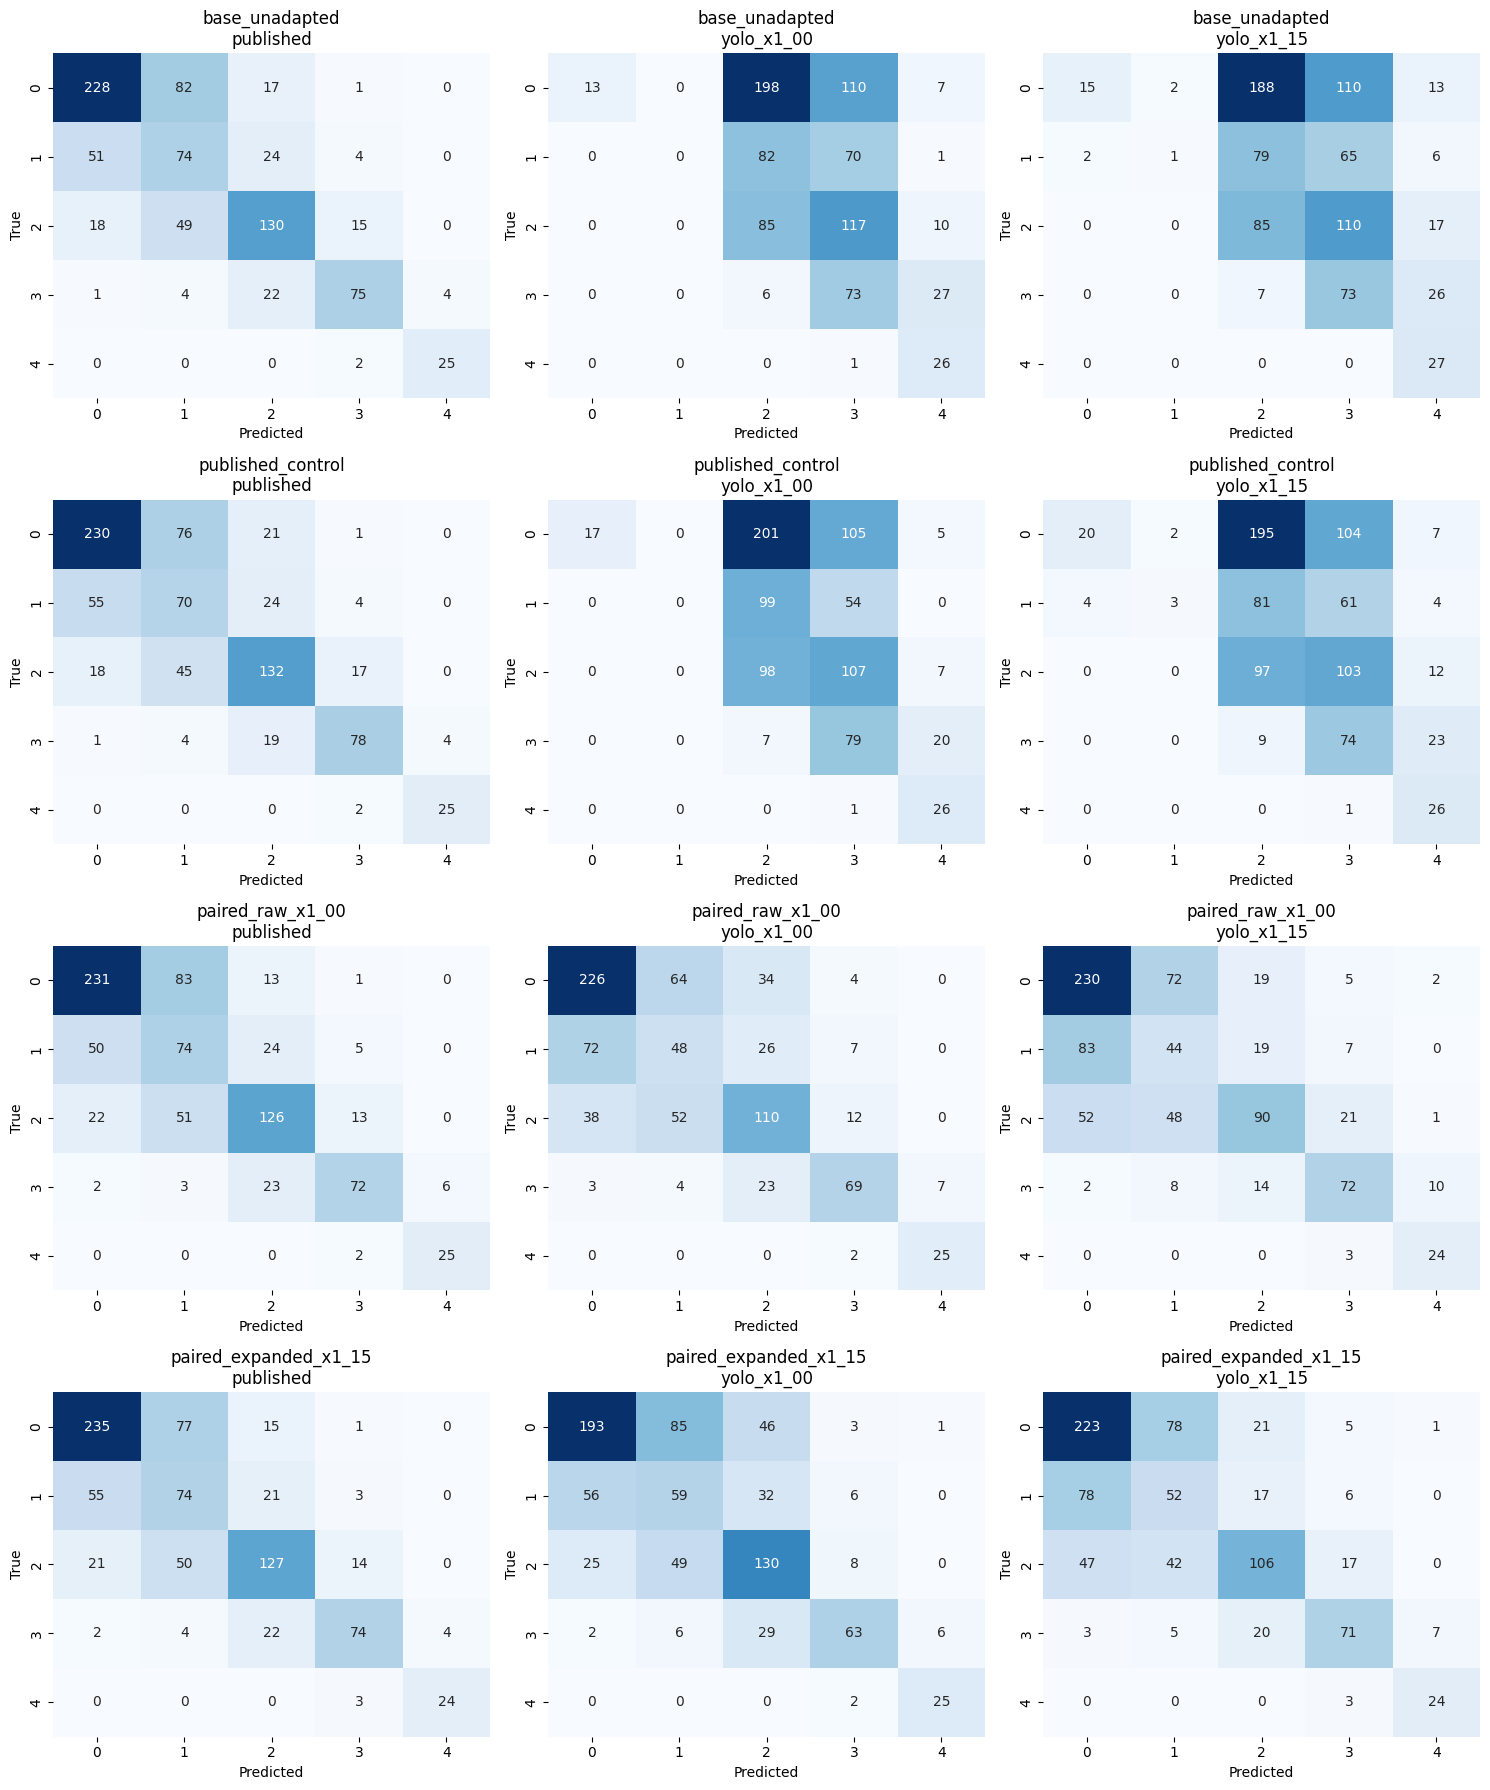

In [9]:
evaluation_rows = []
confusion_payload = {}
candidate_checkpoints = {'base_unadapted': BASE_CHECKPOINT, **arm_checkpoints}
domain_frames = {
    'published': make_frame('val', 1.00),
    'yolo_x1_00': make_frame('val', 1.00),
    'yolo_x1_15': make_frame('val', 1.15),
}

for candidate_name, checkpoint_path in candidate_checkpoints.items():
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    model = DenseNet121Model().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    for domain, frame in domain_frames.items():
        eval_domain = 'published' if domain == 'published' else domain.replace('yolo_', '')
        metrics, labels, predictions = evaluate(model, frame, eval_domain)
        row = {'arm': candidate_name, 'domain': domain, **{k: v for k, v in metrics.items() if k != 'domain'}}
        evaluation_rows.append(row)
        confusion_payload[(candidate_name, domain)] = (labels, predictions)

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df.to_csv(LOCAL_RUN_DIR / 'cross_domain_metrics.csv', index=False)
display(evaluation_df)

domain_scores = evaluation_df.pivot(index='arm', columns='domain', values='selection_score')
robust_scores = domain_scores.mean(axis=1).rename('three_domain_score')
published = evaluation_df[evaluation_df.domain == 'published'].set_index('arm')
control = published.loc['base_unadapted']
guardrail = (
    (published.qwk >= control.qwk - 0.01)
    & (published.macro_f1 >= control.macro_f1 - 0.01)
    & (published.macro_ap >= control.macro_ap - 0.01)
).rename('published_guardrail')
selection_df = pd.concat([robust_scores, guardrail], axis=1).reset_index()
eligible = selection_df[selection_df.published_guardrail]
winner_name = eligible.sort_values('three_domain_score', ascending=False).iloc[0].arm
selection_df['selected'] = selection_df.arm == winner_name
selection_df.to_csv(LOCAL_RUN_DIR / 'selection.csv', index=False)
display(selection_df)
print('Selected arm:', winner_name)

fig, axes = plt.subplots(len(candidate_checkpoints), 3, figsize=(15, 18))
for row_index, candidate_name in enumerate(candidate_checkpoints):
    for column_index, domain in enumerate(domain_frames):
        labels, predictions = confusion_payload[(candidate_name, domain)]
        sns.heatmap(confusion_matrix(labels, predictions), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[row_index, column_index])
        axes[row_index, column_index].set_title(f"{candidate_name}\n{domain}")
        axes[row_index, column_index].set_xlabel('Predicted')
        axes[row_index, column_index].set_ylabel('True')
plt.tight_layout()
confusion_path = LOCAL_RUN_DIR / 'cross_domain_confusion_matrices.png'
plt.savefig(confusion_path, dpi=160, bbox_inches='tight')
plt.show()

## Compact Grad-CAM comparison

Five target-domain validation examples per grade are shown for the untouched checkpoint and each arm. This is a qualitative comparison only; the classification guardrail remains mandatory.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


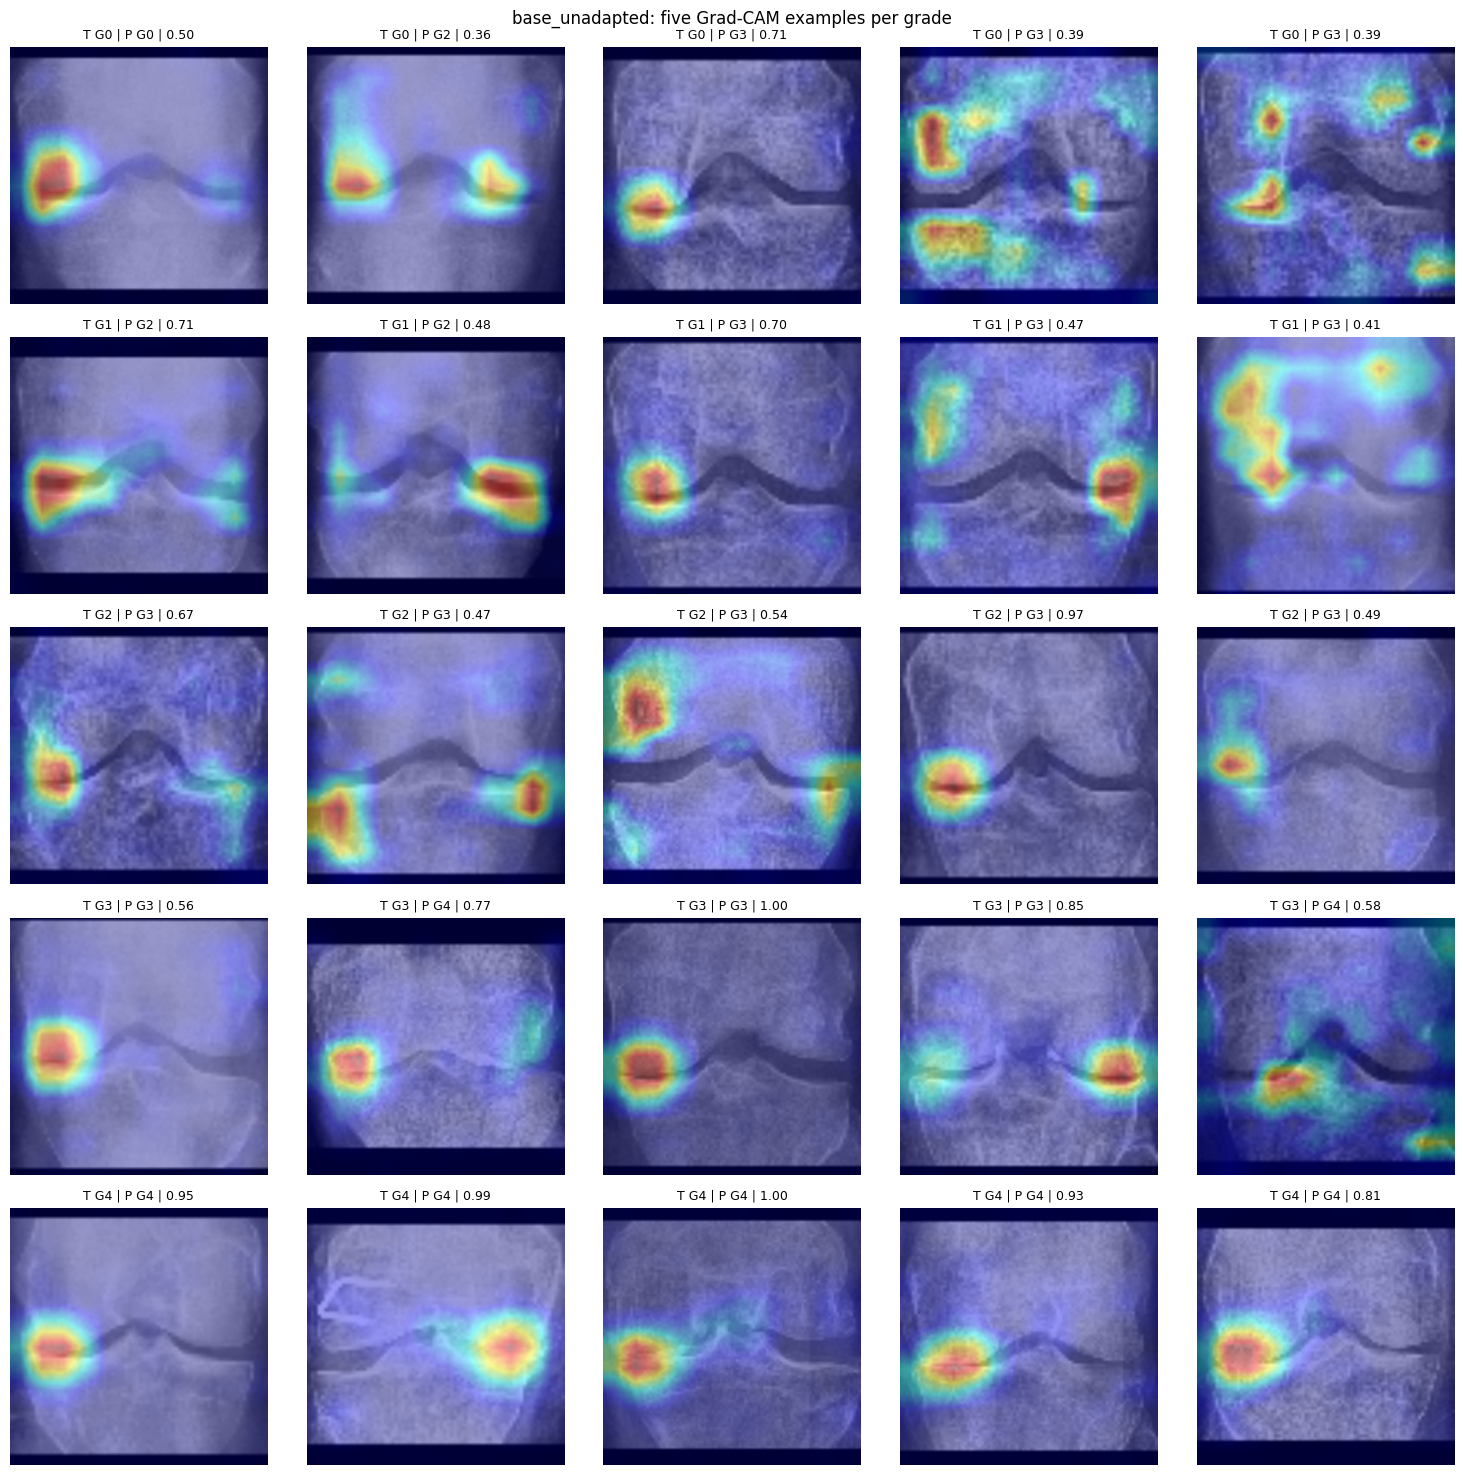

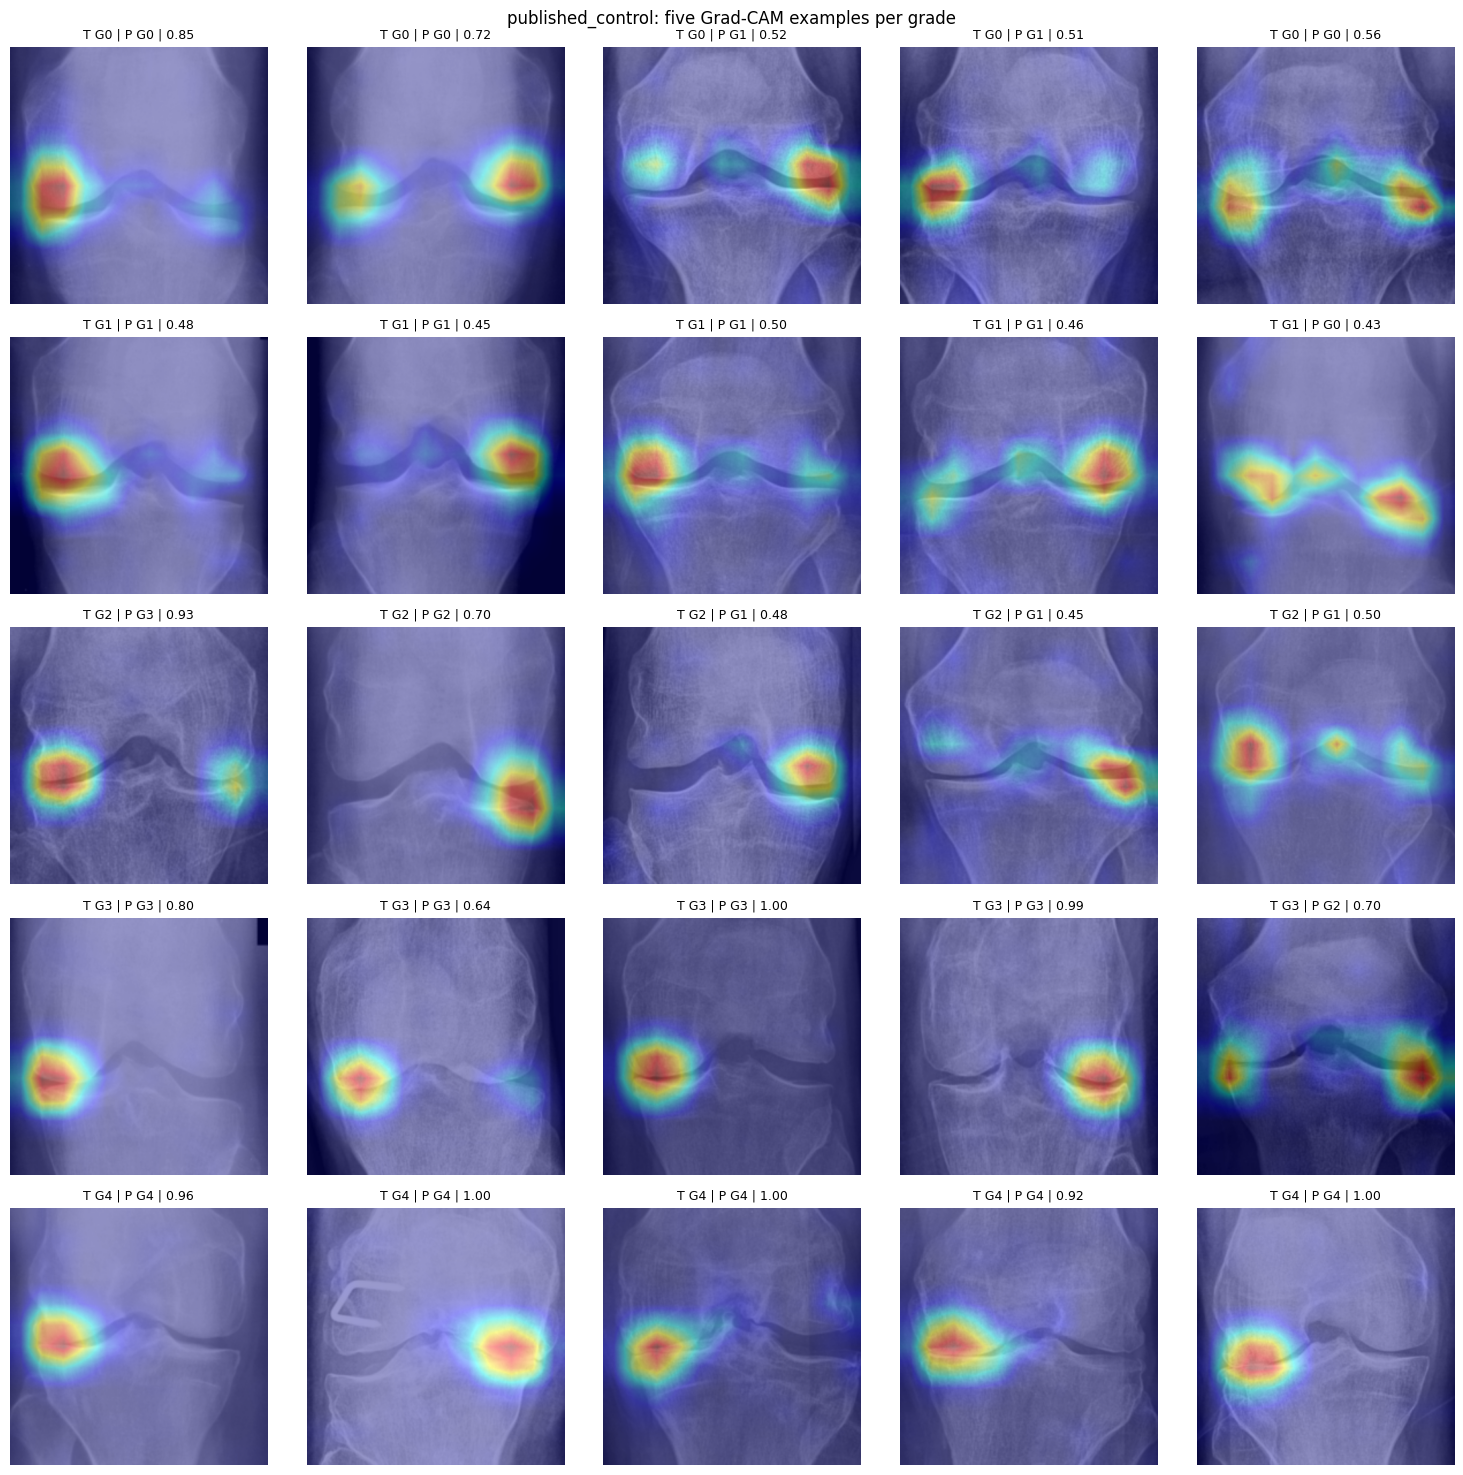

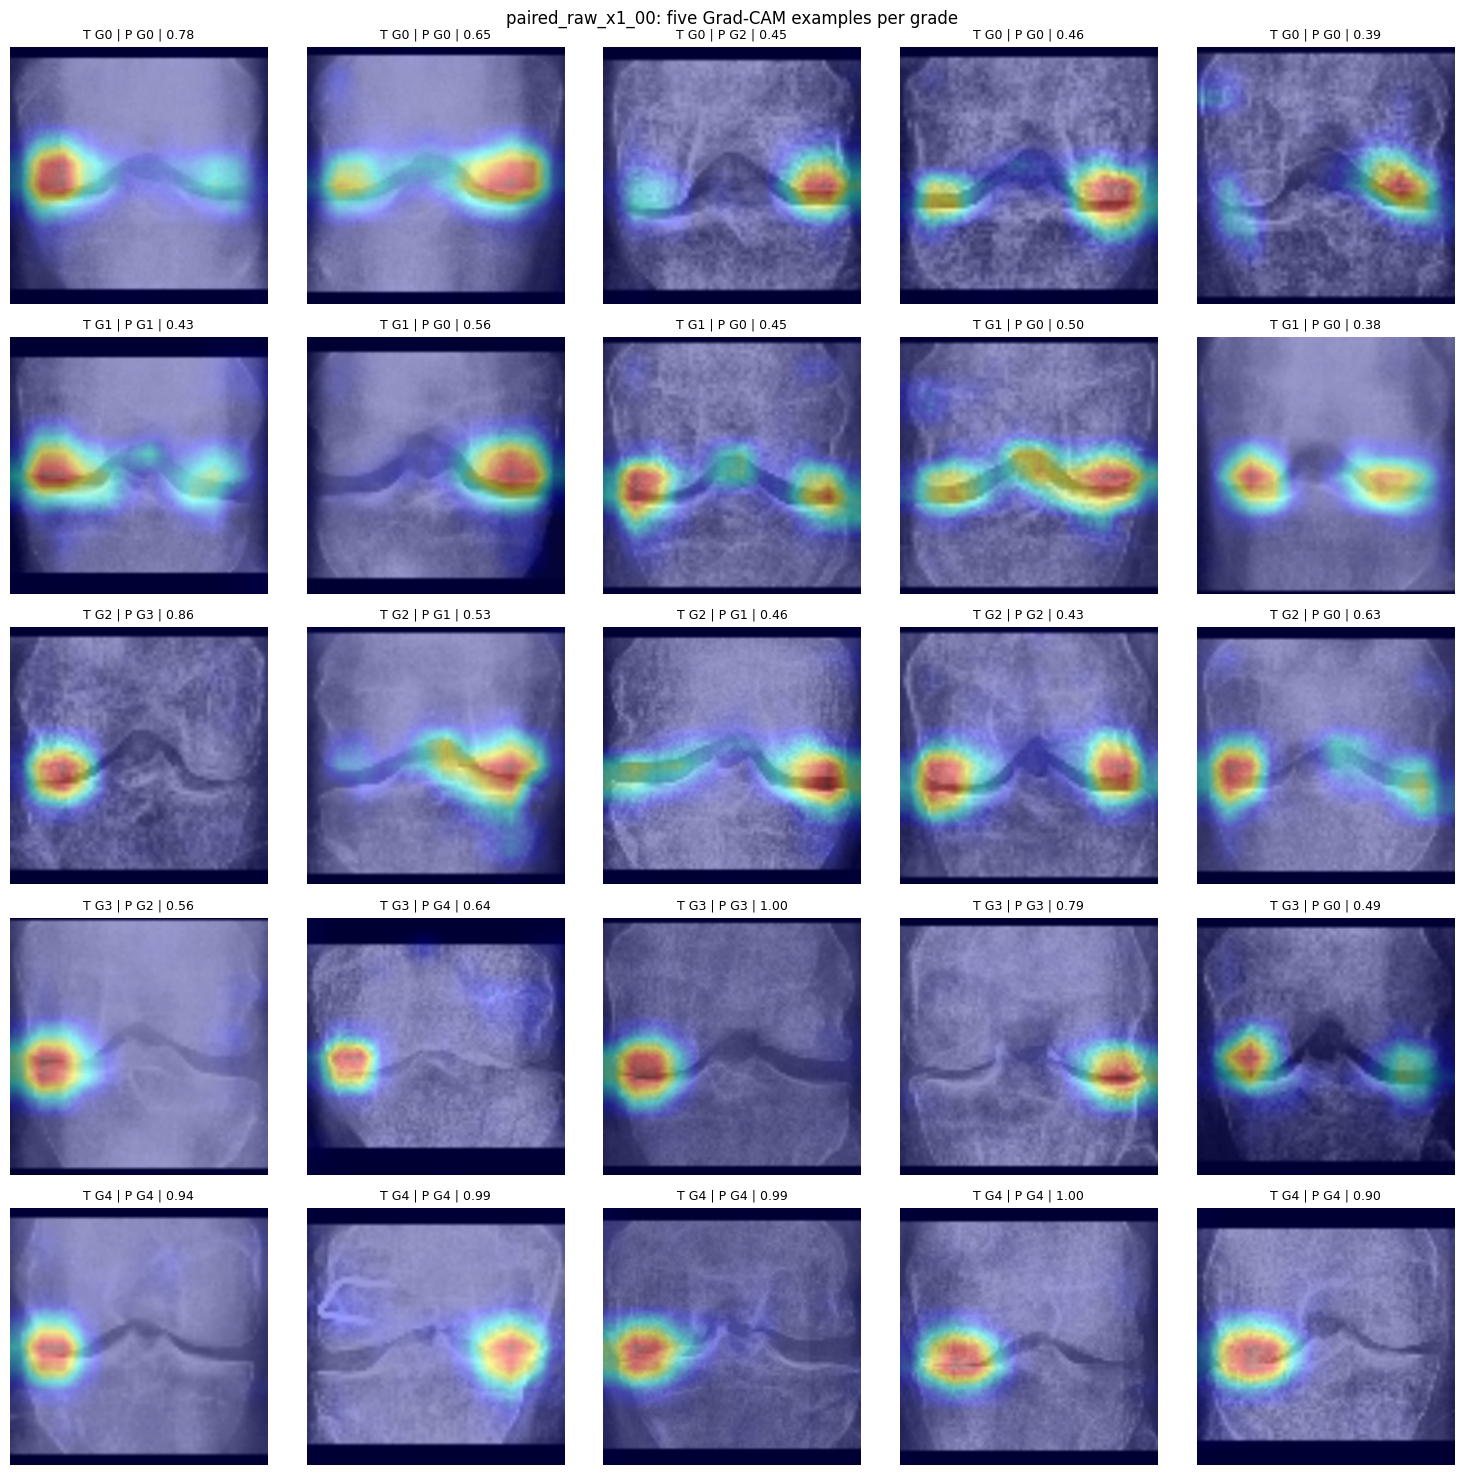

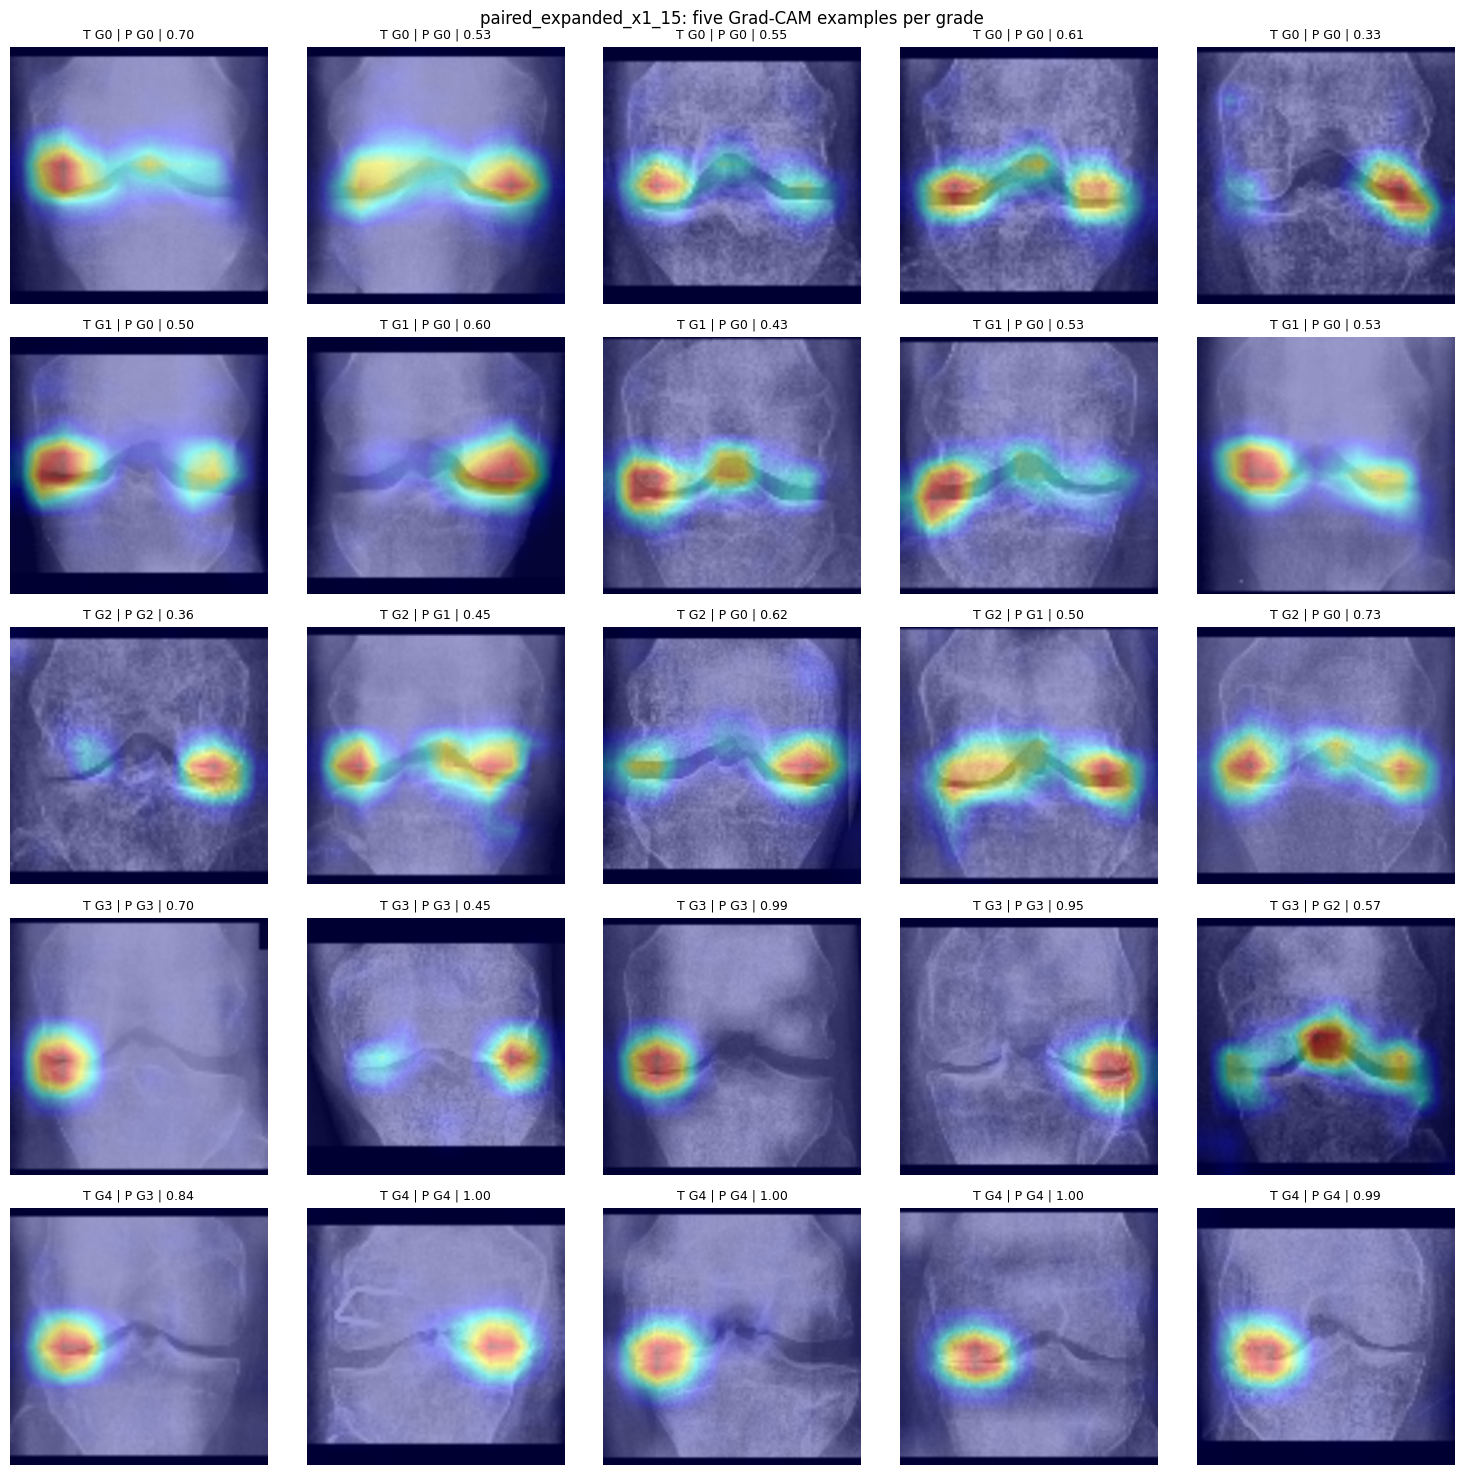

In [10]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = model.gradcam_target_layer.register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.activations = output
        if output.requires_grad:
            output.register_hook(lambda gradient: setattr(self, 'gradients', gradient))

    def remove(self):
        self.handle.remove()

    def __call__(self, tensor):
        self.model.zero_grad(set_to_none=True)
        grad_input = tensor.detach().clone().requires_grad_(True)
        with torch.enable_grad():
            logits = self.model(grad_input)
            predicted = int(logits.argmax(dim=1).item())
            logits[0, predicted].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=tensor.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
        cam = cam.detach().float().cpu().numpy()
        cam = cam / float(cam.max()) if float(cam.max()) > 1e-8 else np.zeros_like(cam)
        confidence = float(F.softmax(logits.detach(), dim=1)[0, predicted].item())
        return predicted, confidence, cam


def prepare(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    processed = OpenCVCLAHE()(rgb)
    processed = SquarePad()(processed)
    processed = np.asarray(Image.fromarray(processed).resize(
        (INPUT_SIZE, INPUT_SIZE), resample=Image.Resampling.BILINEAR
    ))
    tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])(processed).unsqueeze(0).to(DEVICE)
    return rgb, processed, tensor


def overlay(image, cam):
    heatmap = cv2.applyColorMap(np.uint8(np.clip(cam, 0, 1) * 255), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(image, 0.60, heatmap, 0.40, 0)


cam_rows = []
cam_specs = ({'name': 'base_unadapted', 'alternate_factor': None}, *ARM_SPECS)
for spec in cam_specs:
    checkpoint = torch.load(candidate_checkpoints[spec['name']], map_location='cpu', weights_only=False)
    model = DenseNet121Model().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    model.eval()
    cam_engine = GradCAM(model)
    factor = spec['alternate_factor'] if spec['alternate_factor'] is not None else 1.00
    frame = make_frame('val', factor)
    selected = pd.concat([group.head(5) for _, group in frame.groupby('grade')], ignore_index=True)
    figure, axes = plt.subplots(5, 5, figsize=(15, 15))
    for grade in GRADES:
        grade_rows = selected[selected.grade == grade].reset_index(drop=True)
        for column, row in grade_rows.iterrows():
            path = row.published_path if spec['name'] == 'published_control' else row.alternate_path
            _, processed, tensor = prepare(path)
            predicted, confidence, cam = cam_engine(tensor)
            axes[grade, column].imshow(overlay(processed, cam))
            axes[grade, column].set_title(f'T G{grade} | P G{predicted} | {confidence:.2f}', fontsize=9)
            axes[grade, column].axis('off')
            cam_rows.append({'arm': spec['name'], 'grade': grade, 'filename': Path(path).name, 'predicted_grade': predicted, 'confidence': confidence})
    cam_engine.remove()
    figure.suptitle(f"{spec['name']}: five Grad-CAM examples per grade")
    figure.tight_layout()
    path = LOCAL_RUN_DIR / f"{spec['name']}_gradcam_examples.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(figure)

pd.DataFrame(cam_rows).to_csv(LOCAL_RUN_DIR / 'gradcam_examples.csv', index=False)

## Report and archive

In [11]:
winner_checkpoint = candidate_checkpoints[winner_name]
selected_export_path = LOCAL_RUN_DIR / 'selected_best_model.pth'
shutil.copy2(winner_checkpoint, selected_export_path)
config = {
    'run_timestamp_utc': RUN_TIMESTAMP,
    'purpose': 'paired published/production-YOLO view adaptation',
    'test_accessed': False,
    'base_checkpoint': str(BASE_CHECKPOINT),
    'base_sha256': base_sha256,
    'yolo_checkpoint': str(YOLO_CHECKPOINT),
    'yolo_sha256': yolo_sha256,
    'arms': list(ARM_SPECS),
    'epochs_per_arm': EPOCHS,
    'alternate_view_probability': ALTERNATE_VIEW_PROBABILITY,
    'selected_arm': winner_name,
    'selected_checkpoint_source': str(winner_checkpoint),
    'selected_checkpoint_export': str(selected_export_path),
    'limitation': 'YOLO views originate from 256x320 bilateral HDF5 images',
}
(LOCAL_RUN_DIR / 'run_config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')

report = [
    '# DenseNet-121 Paired-View YOLO Crop Adaptation', '',
    f'- Run: `{RUN_NAME}`',
    '- Test accessed: **False**',
    f'- Selected arm: **{winner_name}**',
    f'- Base DenseNet SHA-256: `{base_sha256}`',
    f'- YOLO SHA-256: `{yolo_sha256}`', '',
    '## Selection', '', selection_df.to_markdown(index=False), '',
    '## Cross-Domain Metrics', '',
    evaluation_df[['arm','domain','accuracy','qwk','macro_f1','grade1_recall','macro_ap','macro_auc','mae','selection_score']].to_markdown(index=False), '',
    '## Interpretation', '',
    'The winner must preserve published-crop performance while improving the mean score across published, raw-YOLO, and 1.15x-YOLO validation domains.',
    'The generated YOLO views are low-resolution robustness views, not replacements for the published crops.',
]
(LOCAL_RUN_DIR / 'REPORT.md').write_text('\n'.join(report), encoding='utf-8')

DRIVE_RUN_DIR.parent.mkdir(parents=True, exist_ok=True)
shutil.copytree(LOCAL_RUN_DIR, DRIVE_RUN_DIR, dirs_exist_ok=True)
archive_path = shutil.make_archive(str(LOCAL_RUN_DIR), 'zip', LOCAL_RUN_DIR)
shutil.copy2(archive_path, DRIVE_RUN_DIR.parent / Path(archive_path).name)
print('Selected arm:', winner_name)
print('Report:', DRIVE_RUN_DIR / 'REPORT.md')
print('Artifacts:', DRIVE_RUN_DIR)

Selected arm: paired_expanded_x1_15
Report: /content/drive/MyDrive/Models/densenet121_paired_view_ablations/2026-07-29_12-21-26_272367_UTC_paired_view_yolo_crop_adaptation/REPORT.md
Artifacts: /content/drive/MyDrive/Models/densenet121_paired_view_ablations/2026-07-29_12-21-26_272367_UTC_paired_view_yolo_crop_adaptation


In [12]:
try:
    from google.colab import runtime
    print('Experiment complete. Releasing the Colab runtime...')
    runtime.unassign()
except ImportError:
    print('Not running in Colab; runtime release skipped.')

Experiment complete. Releasing the Colab runtime...
